In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Flatten,Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [10]:
df=pd.read_csv("/content/IMDB_dataset.csv")
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [11]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [12]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [13]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [15]:
df.isnull().sum()

,0
review,0
sentiment,0


In [16]:
df.shape

(50000, 2)

In [17]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [19]:
print(df['sentiment'].value_counts)

<bound method IndexOpsMixin.value_counts of 0        positive
1        positive
2        positive
3        negative
4        positive
           ...   
49995    positive
49996    negative
49997    negative
49998    negative
49999    negative
Name: sentiment, Length: 50000, dtype: object>


In [20]:
# take input and output features

X=df['review']
y=df['sentiment']

In [21]:
# ann works with numbers so, convert into binary
y=y.map({"positive":1,"negative":0})

In [22]:
# train and test split (80% for training and 20% for testing)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=35)

In [23]:
# to convert words into numbers
tokenizer=Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)


In [24]:
# convert reviews into sequences
X_train_seq=tokenizer.texts_to_sequences(X_train)
X_test_seq=tokenizer.texts_to_sequences(X_test)

In [26]:
max_length=200
X_train_pad=pad_sequences(X_train_seq,maxlen=max_length)
X_test_pad=pad_sequences(X_test_seq,maxlen=max_length)
# now every reviews contains max 200 words

In [27]:
# build ann
model=Sequential()
model.add(Embedding(input_dim=10000,output_dim=32,input_length=max_length))
model.add(Flatten())
model.add(Dense(32,activation="relu"))
model.add(Dense(16,activation="relu"))
model.add(Dense(1,activation="sigmoid"))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [28]:
# compile the model
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [29]:
model.summary()#check the model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
# train the ann
history=model.fit(X_train_pad,y_train,epochs=8,batch_size=32,validation_split=0.2)

Epoch 1/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 1.0000 - loss: 3.1959e-06 - val_accuracy: 0.8560 - val_loss: 1.4527
Epoch 2/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 1.0000 - loss: 1.8034e-06 - val_accuracy: 0.8558 - val_loss: 1.5185
Epoch 3/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 1.0000 - loss: 1.0207e-06 - val_accuracy: 0.8554 - val_loss: 1.5851
Epoch 4/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 1.0000 - loss: 5.8311e-07 - val_accuracy: 0.8551 - val_loss: 1.6524
Epoch 5/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 1.0000 - loss: 3.3420e-07 - val_accuracy: 0.8553 - val_loss: 1.7198
Epoch 6/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 1.0000 - loss: 1.9167e-07 - val_accuracy: 0.8553 - val_loss: 1.7855
Epoch 7/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 1.0000 - loss: 1.1045e-07 - val_accuracy: 0.8550 - val_loss: 1.8528
Epoch 8/8
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step 

In [42]:
loss,accuracy=model.evaluate(X_test_pad,y_test)
print("Test Loss:",loss)
print("Test Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8497 - loss: 1.9632
Test Loss: 1.9632357358932495
Test Accuracy: 0.8496999740600586


In [45]:
user_review=input("Enter your Movie review, share your thoughts: ")
user_sequences=tokenizer.texts_to_sequences([user_review])
user_pad=pad_sequences(user_sequences,maxlen=max_length)
prediction=model.predict(user_pad)
prob=prediction[0][0]

if prob>=0.5:
  print("Positive Review. Nice Thoughts 🥰😍")
  print("Probability: ",round(prob,2)*100,"%")
else:
  print("Negative Review. Sorry for your Inconvenience.😌🙂 ")
  print("Probability: ",round(1-prob,2)*100,"%")



Enter your Movie review, share your thoughts: very mokka film
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Negative Review. Sorry for your Inconvenience.😌🙂 
Probability:  98.0 %


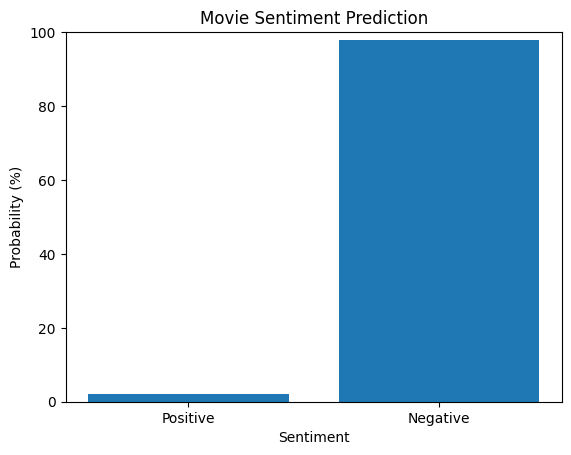

In [46]:
# for graphical representation with respect to user review as bar chart
positive = prob * 100
negative = (1 - prob) * 100

labels = ["Positive", "Negative"]
values = [positive, negative]

plt.bar(labels, values)

plt.title("Movie Sentiment Prediction")
plt.xlabel("Sentiment")
plt.ylabel("Probability (%)")

plt.ylim(0, 100)

plt.show()